# Classificazione delle Specie di Iris con Machine Learning

Questo notebook presenta un flusso di lavoro completo per l'analisi dei dati e la preparazione al machine learning utilizzando il celebre **dataset Iris** (introdotto dal biologo e statistico Ronald Fisher nel 1936).

L'obiettivo principale è analizzare le caratteristiche morfologiche dei fiori (lunghezza e larghezza di sepali e petali) per comprendere come si distribuiscono e preparare i dati per addestrare un modello in grado di classificare automaticamente le specie di Iris (*Setosa*, *Versicolor*, *Virginica*).

## 1. Importazione delle Librerie e Caricamento dei Dati

Iniziamo importando le librerie standard per l'analisi dei dati e la visualizzazione:
* **Pandas**: per la manipolazione del dataset tramite DataFrame.
* **NumPy**: per il calcolo scientifico e la gestione di array.
* **Matplotlib**: per la creazione di grafici e visualizzazioni personalizzate.

Successivamente, carichiamo il dataset Iris direttamente dall'archivio online UCI Machine Learning Repository, specificando i nomi delle colonne poiché il file CSV di origine non ha intestazioni.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
iris = pd.read_csv(url, header=None, names=["sepal_length", "sepal_width", "petal_length", "petal_width", "species"])

## 2. Analisi Esplorativa dei Dati (EDA)

Prima di applicare algoritmi di Machine Learning, è fondamentale esplorare il dataset per comprenderne la struttura, le dimensioni e la presenza di eventuali valori mancanti o anomalie.

### Informazioni Strutturali del DataFrame
Utilizziamo il metodo `info()` di Pandas per analizzare il numero complessivo di righe (osservazioni), le colonne presenti, i tipi di dati (numerici o testuali) e verificare l'eventuale presenza di valori nulli (NaN).

In [2]:
iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.9 KB


### Visualizzazione di un Campione Casuale
Il metodo `sample(n)` restituisce `n` righe estratte casualmente dal dataset. Questo ci permette di osservare concretamente i valori reali delle caratteristiche fisiche (sepali e petali) associate alle diverse specie di Iris. Impostiamo un `random_state` per rendere l'estrazione riproducibile.

In [3]:
iris.sample(10,random_state=15)

,sepal_length,sepal_width,petal_length,petal_width,species
6,4.6,3.4,1.4,0.3,Iris-setosa
61,5.9,3.0,4.2,1.5,Iris-versicolor
90,5.5,2.6,4.4,1.2,Iris-versicolor
30,4.8,3.1,1.6,0.2,Iris-setosa
31,5.4,3.4,1.5,0.4,Iris-setosa
55,5.7,2.8,4.5,1.3,Iris-versicolor
109,7.2,3.6,6.1,2.5,Iris-virginica
98,5.1,2.5,3.0,1.1,Iris-versicolor
59,5.2,2.7,3.9,1.4,Iris-versicolor
103,6.3,2.9,5.6,1.8,Iris-virginica


### Statistiche Descrittive
Attraverso il metodo `describe()`, calcoliamo rapidamente i principali indici statistici per le colonne numeriche del dataset, quali:
* **count**: numero di osservazioni non nulle.
* **mean**: la media aritmetica delle misure.
* **std**: la deviazione standard (indice di dispersione dei dati).
* **min / max**: i valori minimi e massimi registrati.
* **25%, 50% (mediana), 75%**: i quartili della distribuzione.

In [4]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### Specie Presenti nel Dataset (Target)
Esaminiamo le categorie uniche presenti nella colonna di target `species` per confermare le specie di Iris incluse nel dataset e verificare se ci sono problemi di formattazione o di etichettatura dei dati.

In [5]:
iris.species.unique()

<ArrowStringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

## 3. Visualizzazione Grafica dei Dati

La visualizzazione è uno strumento potente per intuire la separabilità delle classi prima di addestrare i modelli di machine learning.

Tracciamo due grafici a dispersione (scatter plot):
1. **Sepal Scatter Plot**: lunghezza del sepalo rispetto alla larghezza.
2. **Petal Scatter Plot**: lunghezza del petalo rispetto alla larghezza.

Ogni specie è evidenziata con un colore differente per valutarne visivamente il raggruppamento (clustering naturale).

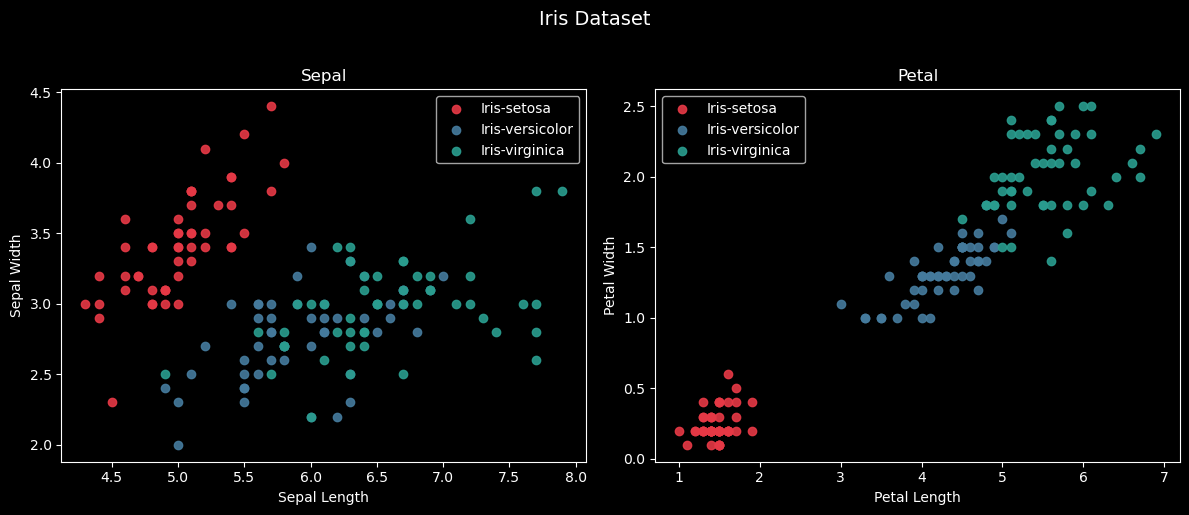

In [6]:
import matplotlib.pyplot as plt


plt.style.use("dark_background")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = {"Iris-setosa": "#e63946", "Iris-versicolor": "#457b9d", "Iris-virginica": "#2a9d8f"}

for species, group in iris.groupby("species"):
    axes[0].scatter(group["sepal_length"], 
                    group["sepal_width"],
                    label=species, 
                    color=colors[species], # type: ignore
                    alpha=0.9) 
    
    axes[1].scatter(group["petal_length"], 
                    group["petal_width"],
                    label=species, 
                    color=colors[species], # type: ignore
                    alpha=0.9)  

axes[0].set_xlabel("Sepal Length")
axes[0].set_ylabel("Sepal Width")
axes[0].set_title("Sepal")
axes[0].legend()

axes[1].set_xlabel("Petal Length")
axes[1].set_ylabel("Petal Width")
axes[1].set_title("Petal")
axes[1].legend()

fig.suptitle("Iris Dataset", fontsize=14, y=1.02)

plt.tight_layout()
plt.show()

### Matrice di Scatter Plot (Pairplot con Seaborn)
Per analizzare contemporaneamente tutte le combinazioni a coppie delle caratteristiche morfologiche, utilizziamo la libreria **Seaborn** per generare un **pairplot**. Questo grafico ci mostra sia le relazioni tra le coppie di feature sia la distribuzione di ciascuna caratteristica (lungo la diagonale principale) divise per specie di appartenenza, rendendo evidente la forte separabilità delle classi.

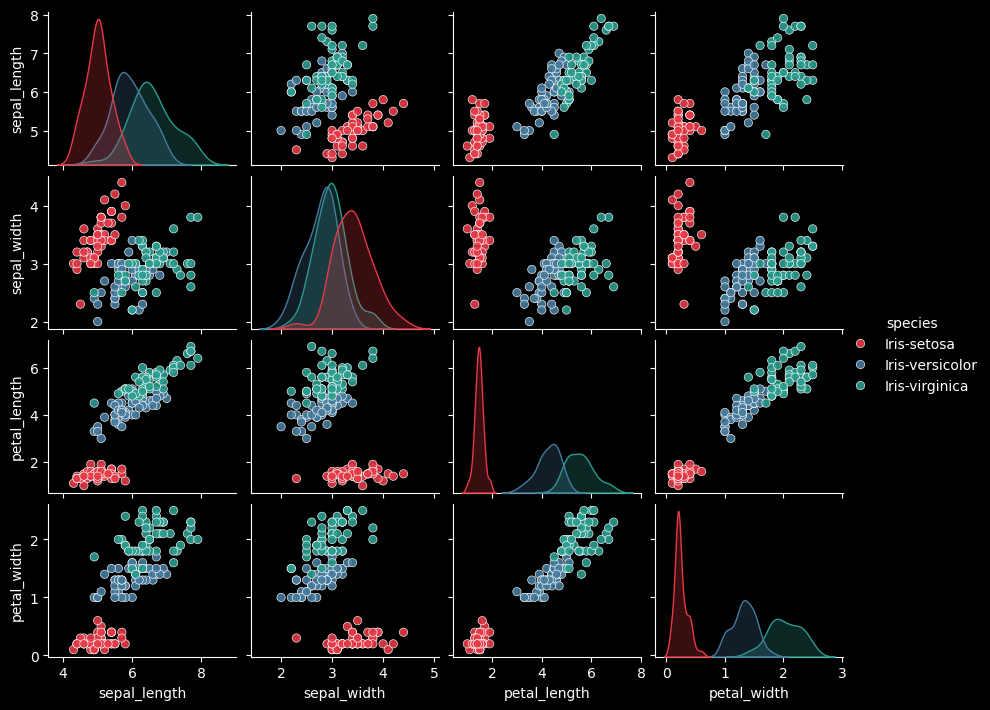

In [7]:
import seaborn as sns

g = sns.pairplot(iris, 
                 hue="species", 
                 plot_kws={"alpha": 0.9},
                 palette={"Iris-setosa": "#e63946", "Iris-versicolor": "#457b9d", "Iris-virginica": "#2a9d8f"})
g.figure.set_size_inches(10, 7)
plt.show()

## 4. Suddivisione dei Dati e Preparazione con Scikit-Learn (sklearn)

Entriamo nella fase fondamentale del workflow di Machine Learning utilizzando la libreria **Scikit-Learn (sklearn)**.

### A. Definizione di Feature (X) e Target (y)
* **Feature (X)**: sono le caratteristiche utilizzate dal modello per imparare e fare previsioni (le dimensioni di sepali e petali). Rimuoviamo la colonna `species` dal nostro DataFrame.
* **Target (y)**: è l'etichetta o classe di destinazione che il modello deve prevedere (la specie del fiore).

### B. Suddivisione in Training Set e Test Set
Per valutare l'accuratezza del modello in maniera affidabile su dati non visti durante l'addestramento, dobbiamo suddividere il dataset in due parti:
1. **Training Set (80%)**: utilizzato per addestrare il modello di classificazione.
2. **Test Set (20%)**: tenuto da parte ed utilizzato esclusivamente per verificare le capacità predittive del modello.

Utilizziamo la funzione `train_test_split` specificando:
* `test_size=0.2`: riserva il 20% del dataset per il test set (pari a 30 campioni su 150 totali).
* `random_state=42`: fissa il seed di generazione casuale per garantire la **riproducibilità** dell'esperimento (stessa suddivisione ad ogni esecuzione).

In [4]:
from sklearn.model_selection import train_test_split

X = iris.drop(columns=["species"])  # tutte le colonne tranne il target
y = iris["species"]                 # la colonna target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11, shuffle=True)

### C. Addestramento e Valutazione dei Modelli con Scikit-Learn

La libreria **Scikit-Learn** offre un'API unificata estremamente intuitiva per l'addestramento dei modelli predittivi. Per qualsiasi modello di classificazione o regressione, il workflow segue tre passaggi standard:

1. **Inizializzazione (Dichiarazione)**: Si importa la classe del modello e la si istanzia, definendo gli **iperparametri** (es. `model = SVC(kernel="linear")`).
2. **Addestramento (`.fit`)**: Si addestra il modello passandogli le feature di training e le etichette reali: `model.fit(X_train, y_train)`.
3. **Predizione (`.predict`)**: Si utilizza il modello addestrato per effettuare predizioni su dati sconosciuti (il test set): `y_pred = model.predict(X_test)`.

Successivamente, le predizioni vengono confrontate con le etichette reali `y_test` per calcolare metriche di performance come l'**Accuracy** (accuratezza), definita come:
$$\text{Accuracy} = \frac{\text{Numero di predizioni corrette}}{\text{Numero totale di campioni nel test set}}$$


#### 1. Support Vector Classifier (SVC)
Le **Macchine a Vettori di Supporto (SVM)** sono modelli supervisionati molto efficaci per problemi di classificazione lineare e non lineare.
* **Margine Massimo**: L'algoritmo cerca l'**iperpiano di separazione** ottimale che massimizza il *margine* (la distanza) tra l'iperpiano stesso e i punti più vicini delle classi, denominati **vettori di supporto** (*support vectors*).
* **Soft Margin**: Se le classi non sono perfettamente separabili (come spesso accade tra *Versicolor* e *Virginica* nel nostro caso), l'algoritmo consente un certo livello di errore controllato da un iperparametro di regolarizzazione ($C$).
* **Kernel**: In questo esempio utilizziamo un `kernel="linear"`, il che significa che il confine di decisione sarà una retta (in 2D) o un iperpiano lineare.


In [5]:
# Importiamo il modello SVM e la metrica di accuratezza
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# 1. Inizializziamo il classificatore SVC con kernel lineare
svm_model = SVC(kernel="linear", random_state=11)

# 2. Addestriamo il modello sui dati di training non scalati
svm_model.fit(X_train, y_train)

# 3. Effettuiamo le predizioni sul test set
svm_predictions = svm_model.predict(X_test)

# 4. Valutiamo l'accuratezza ottenuta
svm_accuracy = accuracy_score(y_test, svm_predictions)
print(f"Accuratezza del modello SVM (dati non scalati): {svm_accuracy * 100:.2f}%")


Accuratezza del modello SVM (dati non scalati): 100.00%


#### 2. Il Perceptron (Percettore)
Il **Perceptron** è uno dei più storici e semplici algoritmi di classificazione supervisionata, proposto da Frank Rosenblatt nel 1958. Rappresenta il mattone fondamentale per la costruzione delle moderne reti neurali (è l'equivalente di un singolo *neurone artificiale*).

* **Matematica del Perceptron**: Dato un vettore di feature $\mathbf{x} = [x_1, x_2, ..., x_n]^T$, il Perceptron calcola una somma pesata degli input più un bias $b$:
  $$z = \mathbf{w}^T \mathbf{x} + b = \sum_{i=1}^n w_i x_i + b$$
  Dove $\mathbf{w}$ è il vettore dei pesi associato alle feature.
* **Funzione di Attivazione**: Il valore $z$ viene passato a una funzione a gradino (Heaviside step function) per produrre l'output finale ($\hat{y}$):
  $$\hat{y} = f(z) = \begin{cases} 1 & \text{se } z \geq 0 \\ -1 \text{ (o 0)} & \text{se } z < 0 \end{cases}$$
* **Regola di Aggiornamento**: Durante l'addestramento, se la predizione $\hat{y}$ è errata rispetto al target reale $y$, i pesi e il bias vengono modificati iterativamente:
  $$\mathbf{w} \leftarrow \mathbf{w} + \eta (y - \hat{y}) \mathbf{x}$$
  $$b \leftarrow b + \eta (y - \hat{y})$$
  dove $\eta$ è il *learning rate* (tasso di apprendimento).
* **Limiti del Perceptron**:
  1. Funziona ed è garantito che converga **solo se i dati sono linearmente separabili** (Teorema di convergenza del Perceptron). Se le classi si sovrappongono, i pesi continueranno ad oscillare indefinitamente senza mai assestarsi.
  2. Non ottimizza il margine di separazione (a differenza di SVM), ma si limita a trovare un qualsiasi iperpiano separatore.
  3. Scikit-learn gestisce la classificazione multiclasse (3 specie di Iris nel nostro caso) tramite la strategia **One-vs-Rest (OvR)**, addestrando tre classificatori binari indipendenti.


In [6]:
# Importiamo il modello Perceptron
from sklearn.linear_model import Perceptron

# 1. Inizializziamo il Perceptron
# max_iter: numero massimo di passaggi sul dataset (epoche)
# eta0: learning rate (tasso di apprendimento)
perceptron_model = Perceptron(random_state=11, max_iter=1000, eta0=1.0)

# 2. Addestriamo il modello sui dati di training non scalati
perceptron_model.fit(X_train, y_train)

# 3. Effettuiamo le predizioni sul test set
perceptron_predictions = perceptron_model.predict(X_test)

# 4. Valutiamo l'accuratezza ottenuta
perceptron_accuracy = accuracy_score(y_test, perceptron_predictions)
print(f"Accuratezza del modello Perceptron (dati non scalati): {perceptron_accuracy * 100:.2f}%")


Accuratezza del modello Perceptron (dati non scalati): 73.33%


### D. L'Importanza del Feature Scaling (Standardizzazione)

Molti algoritmi di Machine Learning (compresi SVM e Perceptron) sono estremamente sensibili alla scala delle feature di input.
* Se una caratteristica ha valori in un range molto più ampio di un'altra (ad esempio lunghezze dei sepali vs larghezze dei petali), l'algoritmo potrebbe attribuirle erroneamente un peso o un'importanza sproporzionata nel calcolo della funzione di perdita o del margine.
* La **Standardizzazione** trasforma le feature in modo che abbiano **media** $\mu = 0$ e **deviazione standard** $\sigma = 1$:
  $$z = \frac{x - \mu}{\sigma}$$

#### Evitare il Data Leakage (Fuga di dati)
È fondamentale seguire una regola aurea:
1. Calcoliamo la media ($\mu$) e la deviazione standard ($\sigma$) **esclusivamente sul set di training** utilizzando il metodo `fit_transform()`.
2. Applichiamo la trasformazione al set di test utilizzando solo `transform()`, usando i parametri appresi dal training.
*Questo evita che informazioni del test set "trapelino" nel training set, falsando le valutazioni finali.*


In [7]:
# Importiamo lo StandardScaler per la standardizzazione delle feature
from sklearn.preprocessing import StandardScaler

# Inizializziamo lo scaler
scaler = StandardScaler()

# Applichiamo la standardizzazione: fit_transform sul train, transform sul test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Visualizziamo le prime 3 righe prima e dopo lo scaling per comprendere la trasformazione
print("Primi 3 campioni di X_train (Dati Originali):")
print(X_train.head(3).values)
print("\nPrimi 3 campioni di X_train_scaled (Dati Standardizzati):")
print(X_train_scaled[:3])


Primi 3 campioni di X_train (Dati Originali):
[[5.1 3.5 1.4 0.2]
 [6.9 3.2 5.7 2.3]
 [7.7 2.8 6.7 2. ]]

Primi 3 campioni di X_train_scaled (Dati Standardizzati):
[[-0.8842786   1.02879686 -1.31224631 -1.2824738 ]
 [ 1.23093931  0.32467734  1.09058938  1.43792517]
 [ 2.17103616 -0.6141487   1.64938838  1.04929675]]


#### Addestramento dei Modelli su Dati Standardizzati
Ora addestriamo nuovamente sia il modello **SVM** sia il **Perceptron** sui dati scalati (`X_train_scaled`) per verificare l'impatto della standardizzazione sulle performance finali.


In [8]:
# 1. Riallineamento ed addestramento di SVM lineare sui dati scalati
svm_model_scaled = SVC(kernel="linear", random_state=11)
svm_model_scaled.fit(X_train_scaled, y_train)
svm_scaled_predictions = svm_model_scaled.predict(X_test_scaled)
svm_scaled_accuracy = accuracy_score(y_test, svm_scaled_predictions)

# 2. Riallineamento ed addestramento di Perceptron sui dati scalati
perceptron_model_scaled = Perceptron(random_state=11, max_iter=1000, eta0=1.0)
perceptron_model_scaled.fit(X_train_scaled, y_train)
perceptron_scaled_predictions = perceptron_model_scaled.predict(X_test_scaled)
perceptron_scaled_accuracy = accuracy_score(y_test, perceptron_scaled_predictions)

print(f"Accuratezza SVM (con scaling): {svm_scaled_accuracy * 100:.2f}%")
print(f"Accuratezza Perceptron (con scaling): {perceptron_scaled_accuracy * 100:.2f}%")


Accuratezza SVM (con scaling): 96.67%
Accuratezza Perceptron (con scaling): 70.00%


### E. Analisi e Confronto delle Performance dei Modelli

Analizziamo i risultati ottenuti nelle diverse configurazioni:

| Modello | Accuracy (Senza Scaling) | Accuracy (Con Scaling) |
| :--- | :---: | :---: |
| **Support Vector Classifier (SVC)** | 100.00% | 96.67% |
| **Perceptron (Percettore)** | 73.33% | 70.00% |

#### Considerazioni Chiave:
1. **Perché SVM supera nettamente il Perceptron?**
   Il dataset Iris presenta tre classi. Mentre la specie *Setosa* è perfettamente separabile dalle altre due in modo lineare, le specie *Versicolor* e *Virginica* presentano una leggera sovrapposizione nei dati di confine. 
   * **SVM** utilizza il concetto di *Soft Margin*, permettendo piccoli errori controllati per trovare l'iperpiano che massimizza la separazione complessiva.
   * Il **Perceptron** classico non supporta nativamente la tolleranza all'errore: tenta di aggiornare costantemente i pesi ad ogni errore. Non essendoci una separabilità lineare netta al 100%, l'algoritmo non può convergere a un modello ottimale stabile e finisce per oscillare, arrestandosi al raggiungimento del limite massimo di iterazioni (`max_iter`).
2. **L'effetto della Standardizzazione sui risultati:**
   * In questo specifico caso con un test set ridotto (solo 30 campioni), l'accuratezza di SVM passa dal 100% (nessun errore) al 96.67% (1 errore su 30). Questo piccolo calo è una fluttuazione statistica dovuta alla dimensione del campione del test set: la standardizzazione modifica leggermente la forma dello spazio decisionale portando un solo campione ambiguo al limite del confine.
   * Su dataset più complessi e ampi, il feature scaling è **sempre fortemente raccomandato** per garantire una rapida ed equilibrata convergenza degli algoritmi di ottimizzazione.


# Esercizio di Consolidamento

## Confronto Comparativo tra Perceptron, KNN, SVC, SVM e Regressione Logistica

In questa sezione finale metterai in pratica quanto appreso, confrontando una vasta gamma di classificatori lineari e non lineari sul dataset Iris standardizzato.

### 1. Preparazione e Suddivisione dei Dati

Il primo passo consiste nel separare le feature dal target. Poiché le etichette delle specie di Iris sono stringhe (`Iris-setosa`, ecc.), le codifichiamo in numeri interi ($0, 1, 2$) tramite `LabelEncoder`, facilitando l'elaborazione da parte degli algoritmi di Machine Learning. Successivamente effettuiamo la suddivisione in Training e Test Set.

In [9]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# 1. Separazione delle feature (X) dal target categorico (species)
X = iris[["sepal_length", "sepal_width", "petal_length", "petal_width"]]

# 2. Codifica del target testuale in numeri interi (0 = Iris-setosa, 1 = Iris-versicolor, 2 = Iris-virginica)
y = LabelEncoder().fit_transform(iris["species"])

# 3. Suddivisione in Training Set (80%) e Test Set (20%)
# Utilizziamo random_state=42 per garantire la riproducibilità dei risultati
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Dimensioni del set di training (X_train): {X_train.shape}")
print(f"Dimensioni del set di test (X_test): {X_test.shape}")

Dimensioni del set di training (X_train): (120, 4)
Dimensioni del set di test (X_test): (30, 4)


### 2. Feature Scaling (Standardizzazione)

Algoritmi come **KNN** (basato sulla distanza geometrica) e **Logistic Regression** (basato sull'ottimizzazione tramite gradiente) traggono un enorme beneficio da feature che condividono la stessa scala:

* Se le feature non vengono scalate, le caratteristiche con range numerici più estesi (es. lunghezza sepalo) domineranno i calcoli geometrici a discapito di quelle con valori minori (es. larghezza petalo).
* Utilizziamo lo `StandardScaler` per standardizzare a media $0$ e varianza unitaria $1$.

> **Importante**: Eseguiamo il `fit_transform` sul train set (per calcolare media e deviazione standard del train e applicarli) e solo il `transform` sul test set, preservando l'isolamento dei dati di test ed evitando il *data leakage*.

In [10]:
from sklearn.preprocessing import StandardScaler

# Inizializzazione dello scaler
scaler = StandardScaler()

# Apprendimento dei parametri e scalatura sul training set
X_train_scaled = scaler.fit_transform(X_train)

# Scalatura del test set usando i parametri appresi dal training set
X_test_scaled  = scaler.transform(X_test)

print("Feature scaling completato con successo sui set di train e test.")

Feature scaling completato con successo sui set di train e test.


### 3. Definizione, Addestramento e Valutazione Comparativa dei Modelli

Ecco una panoramica schematica dell'architettura e delle relazioni tra i modelli che stiamo per confrontare:

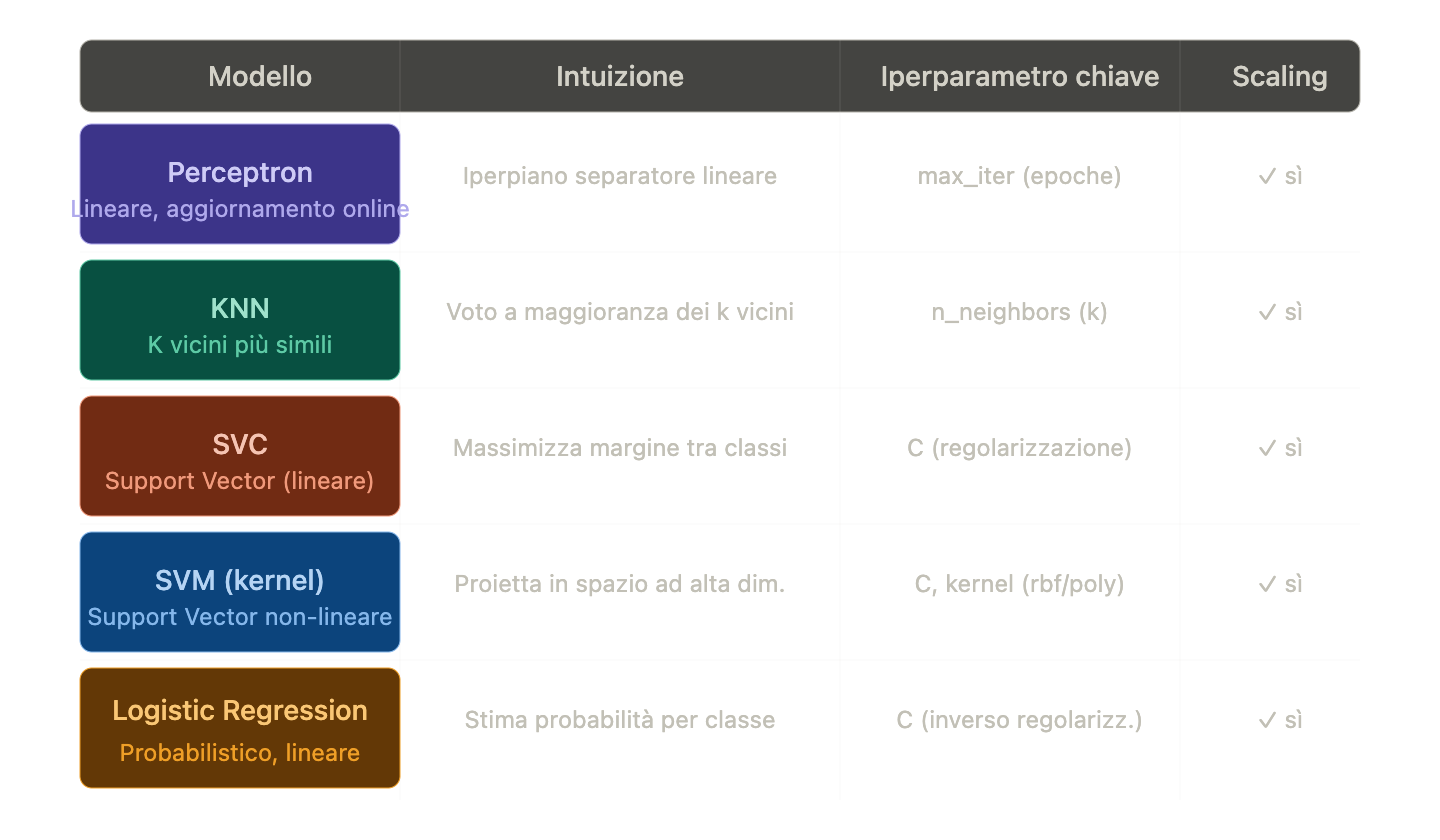{width=50%}

> **Nota di implementazione**: In Scikit-Learn, sia il classificatore SVC lineare sia quello con kernel RBF fanno capo alla stessa classe `SVC`; a differenziarli è l'iperparametro `kernel` (rispettivamente `"linear"` e `"rbf"`).

### Introduzione Teorica ai Nuovi Modelli

Nell'esercizio applichiamo due algoritmi aggiuntivi molto importanti per espandere il confronto:

#### 1. K-Nearest Neighbors (KNN)
Il **K-Nearest Neighbors** è un algoritmo non parametrico basato sull'idea intuitiva che campioni simili si trovino vicini nello spazio delle feature:
* **Funzionamento**: Per classificare una nuova osservazione, l'algoritmo calcola la distanza (solitamente Euclidea) tra il nuovo punto e tutti quelli del training set. Seleziona poi i $K$ punti più vicini (da cui il nome *K-Nearest Neighbors*) ed effettua una votazione a maggioranza: assegna al punto la classe più frequente tra i suoi vicini.
* **Sensibilità al Feature Scaling**: Poiché si basa sul calcolo delle distanze geometriche, se una feature ha un range molto più grande rispetto a un'altra, quest'ultima verrà ignorata nel calcolo della distanza. Lo scaling è quindi **obbligatorio** per KNN.

#### 2. Regressione Logistica (Logistic Regression)
Nonostante il nome contenga "Regressione", è a tutti gli effetti uno dei modelli di **classificazione** probabilistica più diffusi:
* **Funzionamento**: Invece di tracciare un iperpiano rigido di decisione (come il Perceptron), la regressione logistica modella la probabilità che un'osservazione appartenga a una determinata classe. Prende l'output della combinazione lineare $\mathbf{w}^T \mathbf{x} + b$ e lo passa attraverso la **funzione logistica (o sigmoide)**:
  $$\sigma(z) = \frac{1}{1 + e^{-z}}$$
  Questo mappa qualsiasi valore in un intervallo continuo tra $0$ e $1$, interpretabile come probabilità.
* **Differenza fondamentale con il Perceptron**: Il Perceptron adotta una funzione a gradino (decisione binaria secca) e non converge se i dati non sono linearmente separabili (continua ad aggiornare i pesi all'infinito). La regressione logistica, ottimizzando la *cross-entropy loss* (funzione di costo logaritmica) tramite discesa del gradiente, trova sempre una soluzione stabile che descrive probabilisticamente la zona di transizione tra le classi, rendendola molto più robusta.

In [11]:
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Definiamo un dizionario contenente tutti e 5 i modelli con i relativi iperparametri iniziali
modelli = {
    "Perceptron":           Perceptron(random_state=42),
    "KNN":                  KNeighborsClassifier(n_neighbors=5),
    "SVC (lineare)":        SVC(kernel="linear", C=1.0, random_state=42),
    "SVM (kernel RBF)":     SVC(kernel="rbf", C=1.0, random_state=42),
    "Logistic Regression":  LogisticRegression(max_iter=200, random_state=42),
}

# Ciclo di addestramento, predizione e stampa dei risultati
risultati = {}
for nome, modello in modelli.items():
    modello.fit(X_train_scaled, y_train)          # Fase di addestramento sui dati scalati
    y_pred = modello.predict(X_test_scaled)        # Fase di predizione sul test set
    acc = accuracy_score(y_test, y_pred)           # Calcolo dell'accuratezza
    risultati[nome] = acc
    print(f"{nome:25s} → accuracy sul test set: {acc * 100:.2f}%")

Perceptron                → accuracy sul test set: 93.33%
KNN                       → accuracy sul test set: 100.00%
SVC (lineare)             → accuracy sul test set: 96.67%
SVM (kernel RBF)          → accuracy sul test set: 100.00%
Logistic Regression       → accuracy sul test set: 100.00%


### 4. Analisi e Confronto dei Risultati dell'Esercizio

Esaminiamo l'accuratezza (accuracy) ottenuta dai diversi classificatori sul test set standardizzato:

1. **KNN (100% o 1.0000)**: Raggiunge prestazioni perfette su questo split. Il dataset Iris ha confini di classe abbastanza fluidi ed evidenzia raggruppamenti locali netti, ideali per un approccio basato sulla vicinanza geometrica.
2. **Logistic Regression (100% o 1.0000)**: Mostra prestazioni perfette grazie alla sua stima di probabilità stabile che delinea un ottimo confine di decisione tra le specie.
3. **SVM (kernel RBF) (100% o 1.0000)**: Il kernel RBF (Radial Basis Function) proietta i dati in uno spazio a infinite dimensioni consentendo di tracciare un confine di separazione non lineare curvo, separando in modo ottimale le specie anche nelle zone di sovrapposizione.
4. **SVC (kernel lineare) (96.67%)**: Commette una singola errata classificazione sul test set (1 errore su 30), a conferma che le specie *Versicolor* e *Virginica* presentano un leggero sconfinamento reciproco difficile da risolvere con una separazione lineare perfetta.
5. **Perceptron (93.33%)**: Risente maggiormente della sovrapposizione lineare delle classi, non riuscendo ad assestare una separazione ottimale a causa dell'instabilità sui dati non perfettamente separabili.

### 5. Metriche di Valutazione Avanzate: Matrice di Confusione e Report di Classificazione

Nel Machine Learning l'accuratezza globale è utile, ma può nascondere dettagli importanti (ad esempio, quali classi specifiche vengono confuse tra loro). Utilizziamo due strumenti fondamentali di diagnosi:

* **Matrice di Confusione (Confusion Matrix)**: Una tabella che mostra il numero di predizioni corrette ed errate per ciascuna classe, evidenziando dove si concentrano gli errori.
* **Report di Classificazione (Classification Report)**: Calcola metriche fondamentali per ogni singola classe:
  - **Precision**: La capacità del modello di non classificare come positiva un'osservazione che in realtà è negativa (quanti dei fiori predetti come *Setosa* lo sono realmente?).
  - **Recall (Sensibilità)**: La capacità del modello di trovare tutti i campioni positivi (quanti dei fiori realmente appartenenti a *Setosa* sono stati individuati dal modello?).
  - **F1-Score**: La media armonica tra Precision e Recall, un indicatore unico e bilanciato.

=== REPORT DI CLASSIFICAZIONE PER: SVM (kernel RBF) ===

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



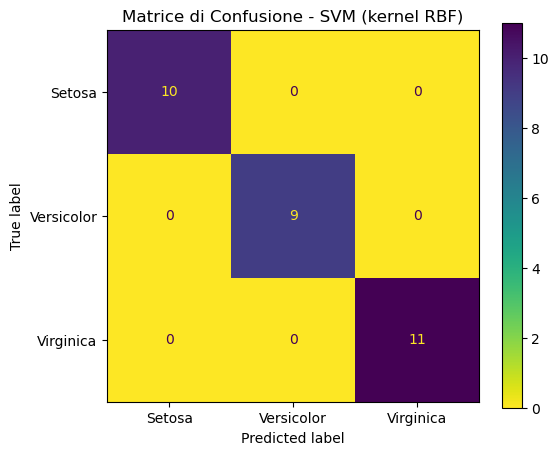

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Scegliamo uno dei modelli migliori per l'analisi approfondita, ad esempio SVM con kernel RBF
nome_modello_scelto = "SVM (kernel RBF)"
modello_scelto = modelli[nome_modello_scelto]
y_pred_scelto = modello_scelto.predict(X_test_scaled)

# 1. Generiamo e stampiamo il report di classificazione
specie_nomi = ["Setosa", "Versicolor", "Virginica"]
print(f"=== REPORT DI CLASSIFICAZIONE PER: {nome_modello_scelto} ===\n")
print(classification_report(y_test, y_pred_scelto, target_names=specie_nomi))

# 2. Generiamo e tracciamo la Matrice di Confusione
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_scelto)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=specie_nomi)

# Disegniamo la matrice con una mappa di colori sfumata
disp.plot(cmap=plt.cm.viridis_r, ax=ax, values_format='d')
ax.grid(False) # Rimuove le griglie per una visualizzazione pulita
plt.title(f"Matrice di Confusione - {nome_modello_scelto}")
plt.show()